## HW2 — Digital FIR Filter (Python Analysis)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

# Parameter Setting
N  = 25       # tap 數
M  = (N-1)//2 # = 12，中心偏移
Ts = 1/6      # 截止頻率參數
bits = np.arange(9, 18) # 9 到 16
threshold = 2 ** -11   # RMSE 門檻（a=11）

# h[n] = sinc(n·Ts)，n = [-12, 12]
h = np.zeros(N)
for i in range(N):
    n = i - M
    t = n * Ts
    h[i] = 1.0 if n == 0 else np.sin(np.pi * t) / (np.pi * t)

# Quantization Function
def quantize(z, b):
    return np.floor(z * 2**b) / 2**b

### Step 1 — Filter Design

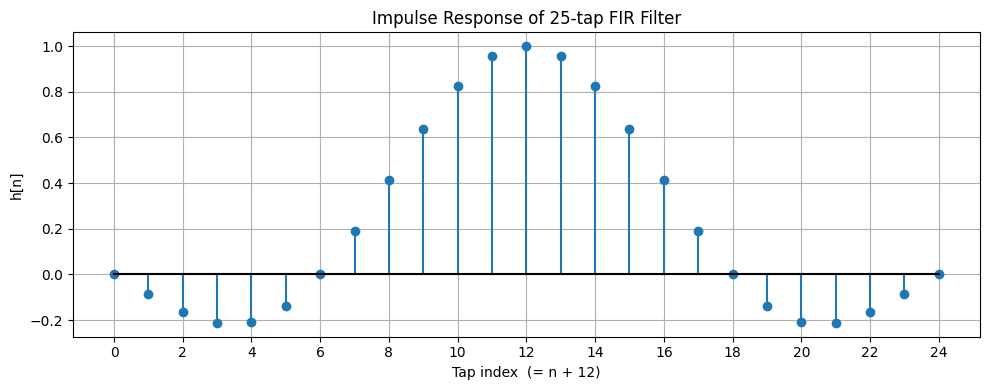

In [2]:
# 脈衝響應
plt.figure(figsize=(10, 4))
plt.stem(range(N), h, basefmt='k-')
plt.title("Impulse Response of 25-tap FIR Filter")
plt.xlabel("Tap index  (= n + 12)")
plt.ylabel("h[n]")
plt.xticks(range(0, N, 2))
plt.grid(True)
plt.tight_layout()
plt.show()

0.140625


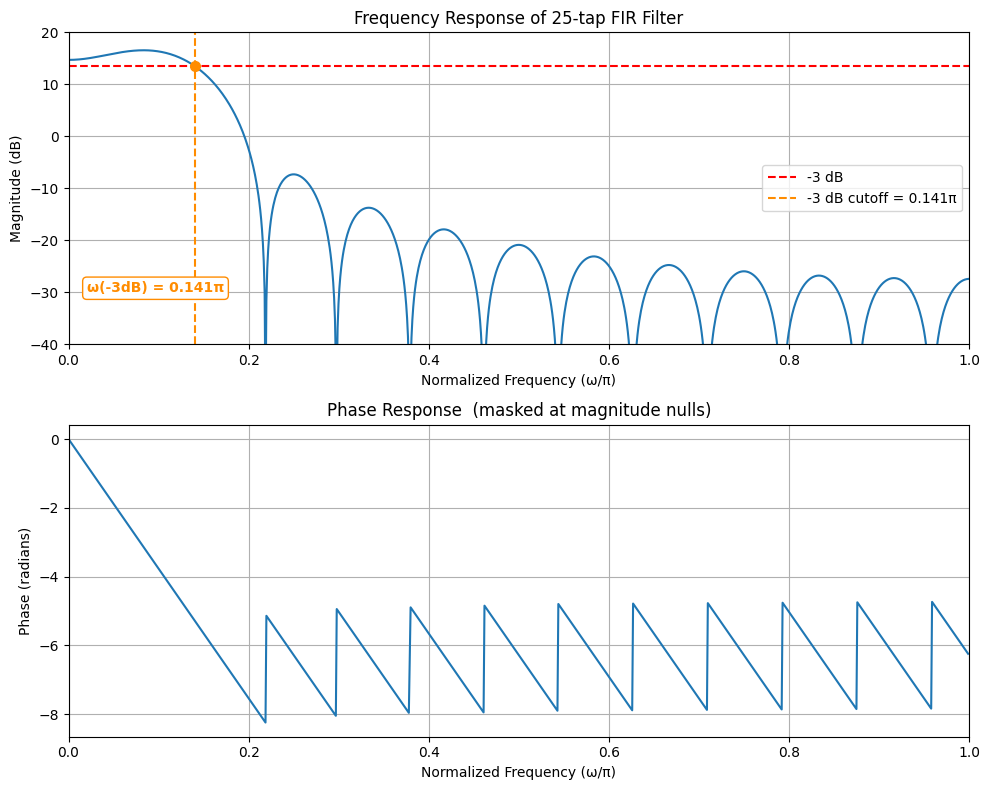

In [3]:
# 頻率響應
w, H = freqz(h, worN=1024) # 把 h[n] 做 DTDT, 回傳 w (1024 個頻率點) & H (頻率響應)
freq_norm    = w / np.pi # 把 w 全部轉正規化頻率
magnitude_dB = 20 * np.log10(np.abs(H)) # 轉 dB (可以加 1e-12，防止 log(0) 畫圖出錯) 
phase_rad    = np.unwrap(np.angle(H)) # 拿出 Phase

# 畫圖
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
ax1.plot(freq_norm, magnitude_dB)
ax1.set_title("Frequency Response of 25-tap FIR Filter")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_xlabel("Normalized Frequency (ω/π)")
ax1.set_xlim([0, 1])
ax1.set_ylim([-40, 20])

# -3dB 截止點標示
# 找出所有小於 -3dB 的點 (因為切出來的離散點不一定落在 -3dB)
# -3dB -> 最大峰值下降 3dB 的位置
idx_3dB = np.where(magnitude_dB <= magnitude_dB.max() - 3)[0]
if len(idx_3dB) > 0:
    f_3dB = freq_norm[idx_3dB[0]] # 最接近 -3dB 點的頻率
    print(f_3dB)
    # 畫圖
    ax1.axhline(magnitude_dB.max() - 3, color='red', linestyle='--', linewidth=1.5, label='-3 dB')
    ax1.axvline(f_3dB, color='darkorange', linestyle='--', linewidth=1.5,
                label=f'-3 dB cutoff = {f_3dB:.3f}π')
    ax1.text(f_3dB/2 - 0.05, -30, f'ω(-3dB) = {f_3dB:.3f}π',
             color='darkorange', fontsize=10, fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='darkorange', boxstyle='round,pad=0.3'))
    ax1.plot(f_3dB, magnitude_dB.max() - 3, 'o', color='darkorange', markersize=7, zorder=5)
ax1.legend()
ax1.grid(True)

# 畫圖
# null 點附近的 phase 不可信，只畫有效區段
valid = np.abs(H) > 1e-4
ax2.plot(freq_norm[valid], phase_rad[valid])
ax2.set_title("Phase Response  (masked at magnitude nulls)")
ax2.set_ylabel("Phase (radians)")
ax2.set_xlabel("Normalized Frequency (ω/π)")
ax2.set_xlim([0, 1])
ax2.grid(True)

plt.tight_layout()
plt.show()

### Step 2 — Evaluate performance 

輸入訊號包含兩個頻率成分：

| 成分 | ω/π | 位置 | 結果 |
|------|-----|------|------|
| sin(−2πn/128) | 0.016 | passband | 通過 |
| −cos(2πn/4) | 0.500 | stopband | 被濾除 |

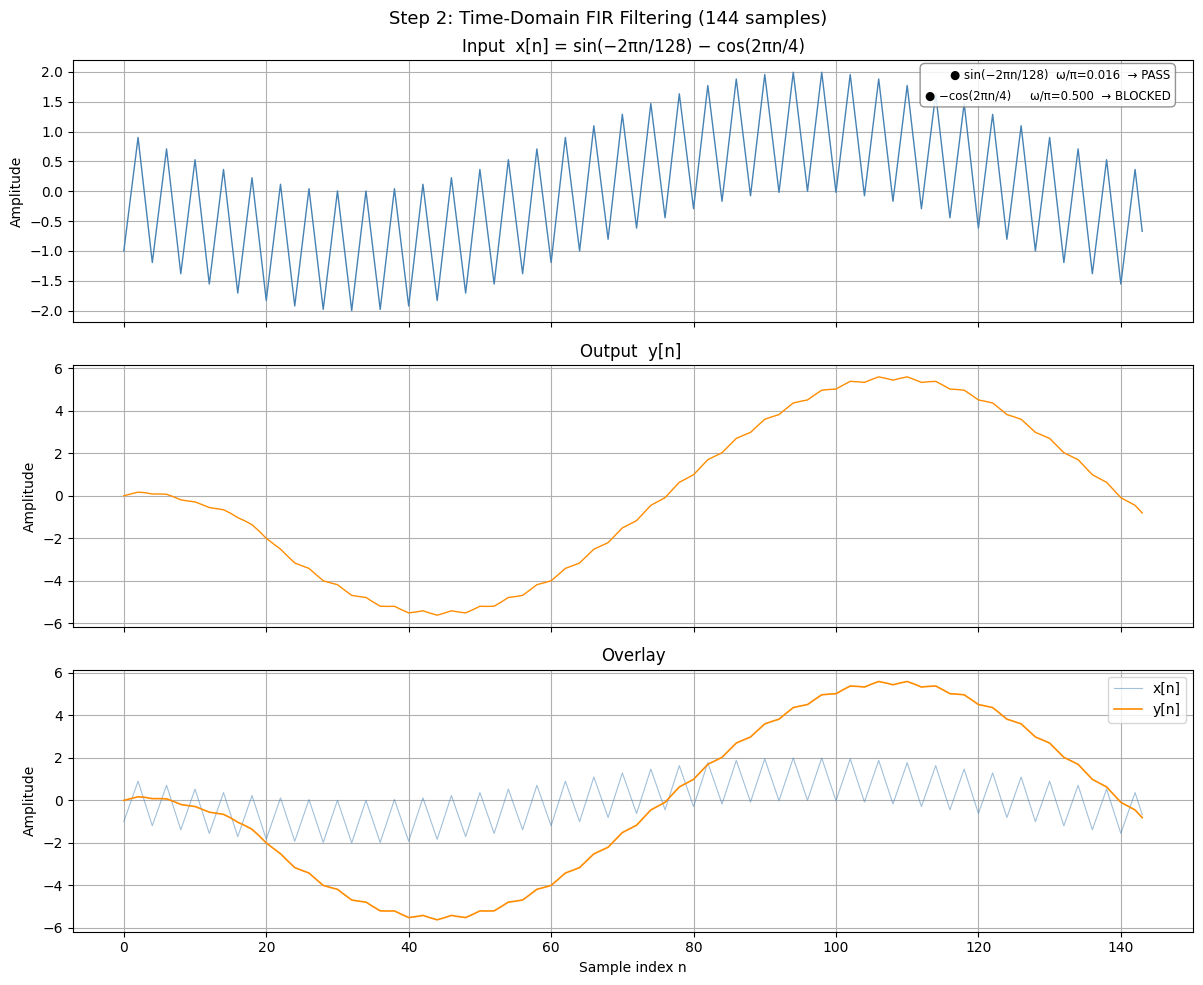

In [4]:
n_idx = np.arange(144)
x = np.sin(-2 * np.pi * n_idx / 128) - np.cos(2 * np.pi * n_idx / 4)

# 線性卷積，取前 144 點（因果濾波器輸出）
y_float = np.convolve(x, h)[:144]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("Step 2: Time-Domain FIR Filtering (144 samples)", fontsize=13)

axes[0].plot(n_idx, x, color='steelblue', linewidth=1)
axes[0].set_title("Input  x[n] = sin(−2πn/128) − cos(2πn/4)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)
axes[0].text(0.98, 0.97,
             "● sin(−2πn/128)  ω/π=0.016  → PASS\n● −cos(2πn/4)     ω/π=0.500  → BLOCKED",
             transform=axes[0].transAxes, fontsize=8.5,
             va='top', ha='right',
             bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85, boxstyle='round,pad=0.4'),
             linespacing=1.8)

axes[1].plot(n_idx, y_float, color='darkorange', linewidth=1)
axes[1].set_title("Output  y[n] ")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True)

axes[2].plot(n_idx, x,       color='steelblue',  linewidth=0.8, alpha=0.5, label='x[n]')
axes[2].plot(n_idx, y_float, color='darkorange',  linewidth=1.2,            label='y[n]')
axes[2].set_title("Overlay")
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Sample index n")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Step 3.A — Find the Best Word-Length after Quantization


In [5]:
def rmse(y_test):
    return np.sqrt(np.mean((y_float - y_test) ** 2))

def first_pass(errors, thr):
    idx = np.where(errors < thr)[0]
    return bits[idx[0]] if len(idx) > 0 else None

def fir(x_in, h_in, b_mult=None, b_add=None):
    L = len(x_in)
    y_out = np.zeros(L)
    x_pad = np.concatenate([np.zeros(N - 1), x_in])   # zero-padding for causality
    for n in range(L):
        acc = 0.0
        for k in range(N):
            prod = h_in[k] * x_pad[n + N - 1 - k]
            if b_mult is not None:
                prod = quantize(prod, b_mult)
            acc += prod
            if b_add is not None:
                acc = quantize(acc, b_add)
        y_out[n] = acc
    return y_out

rmse_A = []
rmse_B = []
rmse_C = []
rmse_D = []

int_x = int(np.floor(np.log2(np.abs(x).max()))) + 2
int_h = int(np.floor(np.log2(np.abs(h).max()))) + 2

# Module A - Scan Input Word-Lengths
for b in bits:
    x_q = quantize(x, b) # 量化 
    y_A = np.convolve(x_q, h)[:144] # 拿量化後的定點數去做捲積
    rmse_A.append(rmse(y_A)) 

rmse_A = np.array(rmse_A)
b_A = first_pass(rmse_A, threshold) # 找出最小符合的 bit
wl_A = b_A + int_x # 定點數所需要的字長

print(f"  Node A : Fix-Point Word Length = {wl_A} | Fractional Word Length = {b_A}")

# Module B - Scan Coefficient Word-lengths (Fix Input Word-Lengths)
for b in bits:
    x_q = quantize(x, b_A) # 量化
    h_q = quantize(h, b) # 量化
    y_B = np.convolve(x_q, h_q)[:144] # 拿量化後的定點數去做捲積
    rmse_B.append(rmse(y_B))

rmse_B = np.array(rmse_B)
b_B = first_pass(rmse_B, threshold) # 找出最小符合的 bit
wl_B = b_B + int_h

print(f"  Node B : Fix-Point Word Length = {wl_B} | Fractional Word Length = {b_B}") 

# Module 3 - Scan Word-Lengths after multiplications (Fix Input & Cofficient Word-Lengths)
for b in bits:
    x_q = quantize(x, b_A) # 量化
    h_q = quantize(h, b_B) # 量化
    y_C = fir(x_q, h_q, b_mult=b, b_add=None)
    rmse_C.append(rmse(y_C))

# 捲積相乘最大值一定是 max(|x|) * max(|h|)
int_mul = int(np.floor(np.log2(np.abs(x_q).max() * np.abs(h_q).max()))) + 2
rmse_C = np.array(rmse_C)
b_C = first_pass(rmse_C, threshold) # 找出最小符合的 bit
wl_C = b_C + int_mul

print(f"  Node C : Fix-Point Word Length = {wl_C} | Fractional Word Length = {b_C}") 

# Module 4 - Scan Word-lengths after addition (Fix Input & Cofficient Word-Lengths and after multiplication)
for b in bits:
    x_q = quantize(x, b_A) # 量化
    h_q = quantize(h, b_B) # 量化
    y_C = fir(x_q, h_q, b_mult=(b_C), b_add=None) # 相加的最大值就直接來找捲積輸出最大值
    int_add = int(np.floor(np.log2(np.abs(y_C).max()))) + 2
    y_D = fir(x_q, h_q, b_mult=(b_C), b_add=(b)) # 相加的最大值就直接找捲積輸出最大值
    rmse_D.append(rmse(y_D))

rmse_D = np.array(rmse_D)
b_D = first_pass(rmse_D, threshold) # 找出最小符合的 bit
wl_D = b_D + int_add

print(f"  Node D : Fix-Point Word Length = {wl_D} | Fractional Word Length = {b_D}") 

  Node A : Fix-Point Word Length = 16 | Fractional Word Length = 13
  Node B : Fix-Point Word Length = 17 | Fractional Word Length = 15
  Node C : Fix-Point Word Length = 20 | Fractional Word Length = 17
  Node D : Fix-Point Word Length = 21 | Fractional Word Length = 17


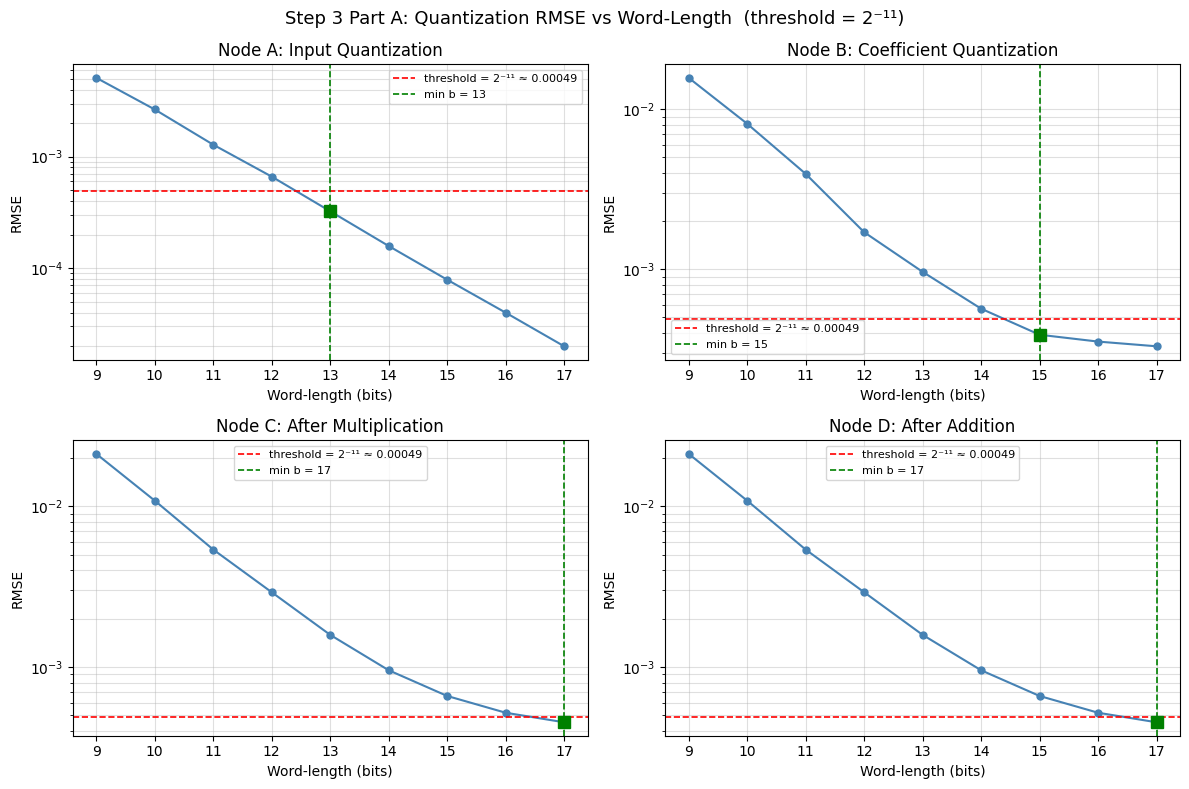

In [6]:
# 畫圖 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Step 3 Part A: Quantization RMSE vs Word-Length  (threshold = 2⁻¹¹)", fontsize=13)

configs = [
    (axes[0, 0], rmse_A, b_A, "Node A: Input Quantization"),
    (axes[0, 1], rmse_B, b_B, "Node B: Coefficient Quantization"),
    (axes[1, 0], rmse_C, b_C, "Node C: After Multiplication"),
    (axes[1, 1], rmse_D, b_D, "Node D: After Addition"),
]

for ax, errors, b_pass, title in configs:
    ax.semilogy(bits, errors, 'o-', color='steelblue', linewidth=1.5, markersize=5)
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2,
               label=f'threshold = 2⁻¹¹ ≈ {threshold:.5f}')
    if b_pass is not None:
        ax.axvline(b_pass, color='green', linestyle='--', linewidth=1.2,
                   label=f'min b = {b_pass}')
        ax.plot(b_pass, errors[b_pass - 9], 's', color='green', markersize=8, zorder=5)
    ax.set_title(title)
    ax.set_xlabel("Word-length (bits)")
    ax.set_ylabel("RMSE")
    ax.set_xticks(bits)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()

### Step 3.B — Find the Best Word-Length after Quantization


In [7]:

y_fixed = fir(x_q, h_q, b_mult=(b_C), b_add=(b_D)) 
error = y_fixed - y_float 
rmse_combined = np.sqrt(np.mean(error ** 2))

print(f"\n=== Combined Fixed-point RMSE ===")
print(f"  RMSE          = {rmse_combined:.8f}")
print(f"  Threshold 2⁻¹¹= {threshold:.8f}")
print(f"{'Pass' if rmse_combined < threshold else 'Fail'}")

# 固定點頻率響應（用量化後的 h_q）
w, H_float = freqz(h,   worN=2048)
w, H_fixed = freqz(h_q, worN=2048)
freq_norm = w / np.pi

mag_float_dB = 20 * np.log10(np.abs(H_float) + 1e-12)
mag_fixed_dB = 20 * np.log10(np.abs(H_fixed) + 1e-12)

# passband 範圍（ω/π < 0.141）
passband_mask = freq_norm < 0.141
mag_err_dB = mag_fixed_dB[passband_mask] - mag_float_dB[passband_mask]

print(f"\n=== Passband Magnitude Error ===")
print(f"  Max error in passband = {np.max(np.abs(mag_err_dB)):.8f} dB")




=== Combined Fixed-point RMSE ===
  RMSE          = 0.00045324
  Threshold 2⁻¹¹= 0.00048828
Pass

=== Passband Magnitude Error ===
  Max error in passband = 0.00054532 dB


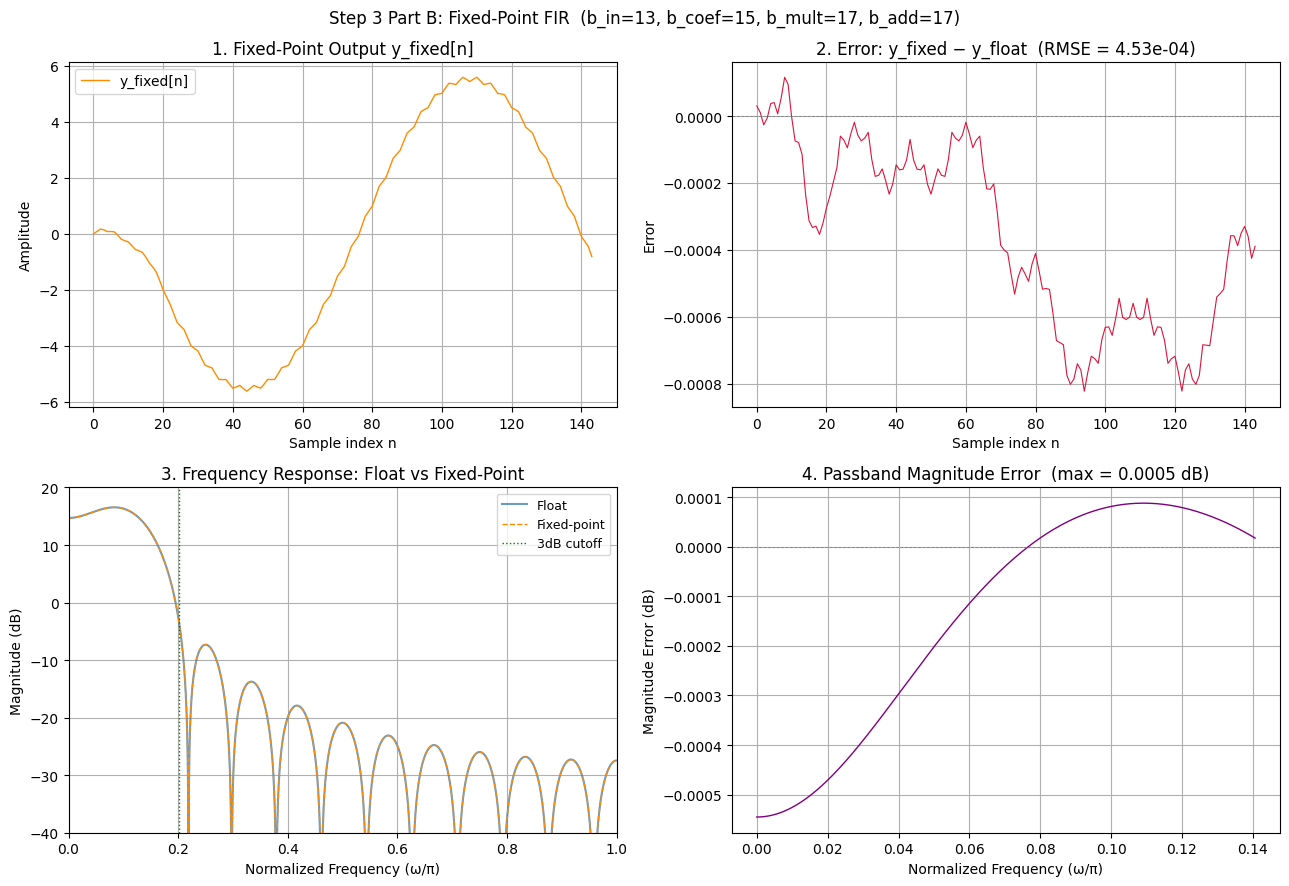

In [8]:
# 畫圖 

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    f"Step 3 Part B: Fixed-Point FIR  "
    f"(b_in={b_A}, b_coef={b_B}, b_mult={b_C}, b_add={b_D})",
    fontsize=12)

#  子圖 1：Fixed-point 時域輸出 
axes[0, 0].plot(n_idx, y_fixed, color='darkorange', linewidth=1, label='y_fixed[n]')
axes[0, 0].set_title("1. Fixed-Point Output y_fixed[n]")
axes[0, 0].set_xlabel("Sample index n")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].legend()
axes[0, 0].grid(True)

#  子圖 2：誤差 y_fixed - y_float 
axes[0, 1].plot(n_idx, error, color='crimson', linewidth=0.8)
axes[0, 1].axhline(0, color='gray', linewidth=0.6, linestyle='--')
axes[0, 1].set_title(f"2. Error: y_fixed − y_float  (RMSE = {rmse_combined:.2e})")
axes[0, 1].set_xlabel("Sample index n")
axes[0, 1].set_ylabel("Error")
axes[0, 1].grid(True)

#  子圖 3：頻率響應對比 
axes[1, 0].plot(freq_norm, mag_float_dB, color='steelblue',
                linewidth=1.5, label='Float', alpha=0.8)
axes[1, 0].plot(freq_norm, mag_fixed_dB, color='darkorange',
                linewidth=1, linestyle='--', label='Fixed-point')
axes[1, 0].axvline(0.201, color='green', linestyle=':', linewidth=1, label='3dB cutoff')
axes[1, 0].set_title("3. Frequency Response: Float vs Fixed-Point")
axes[1, 0].set_xlabel("Normalized Frequency (ω/π)")
axes[1, 0].set_ylabel("Magnitude (dB)")
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([-40, 20])
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True)

#  子圖 4：Passband magnitude 誤差 
axes[1, 1].plot(freq_norm[passband_mask], mag_err_dB,
                color='purple', linewidth=1)
axes[1, 1].axhline(0, color='gray', linewidth=0.6, linestyle='--')
axes[1, 1].set_title(
    f"4. Passband Magnitude Error  (max = {np.max(np.abs(mag_err_dB)):.4f} dB)")
axes[1, 1].set_xlabel("Normalized Frequency (ω/π)")
axes[1, 1].set_ylabel("Magnitude Error (dB)")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### Step 4 Generate the Input File for Hardware Design

In [ ]:
# Generate the X Input File 
x_int = (x_q * 2**b_A).astype(int)  # 直接取定點整數表示
with open('../RTL/src/input.dat', 'w') as f:
    for n in x_int:
        if n < 0:
            n += (1 << 16)             # 二的補數
        f.write(format(n, '016b') + '\n')

# Generate the H File
h_int = (h_q * 2**b_B).astype(int)  # 直接取定點整數表示

with open('../RTL/src/coeff.dat', 'w') as f:
    for n in h_int:
        if n < 0:
            n += (1 << wl_B)          # 二的補數, 17-bit
        f.write(format(n, f'0{wl_B}b') + '\n')


2995
144


### Step 4.B Check Hardware Design Output File 

Hardware samples : 144
Fractional bits  : 17
RMSE (HW vs Float) = 0.00045333
Threshold 2^-11   = 0.00048828
PASS


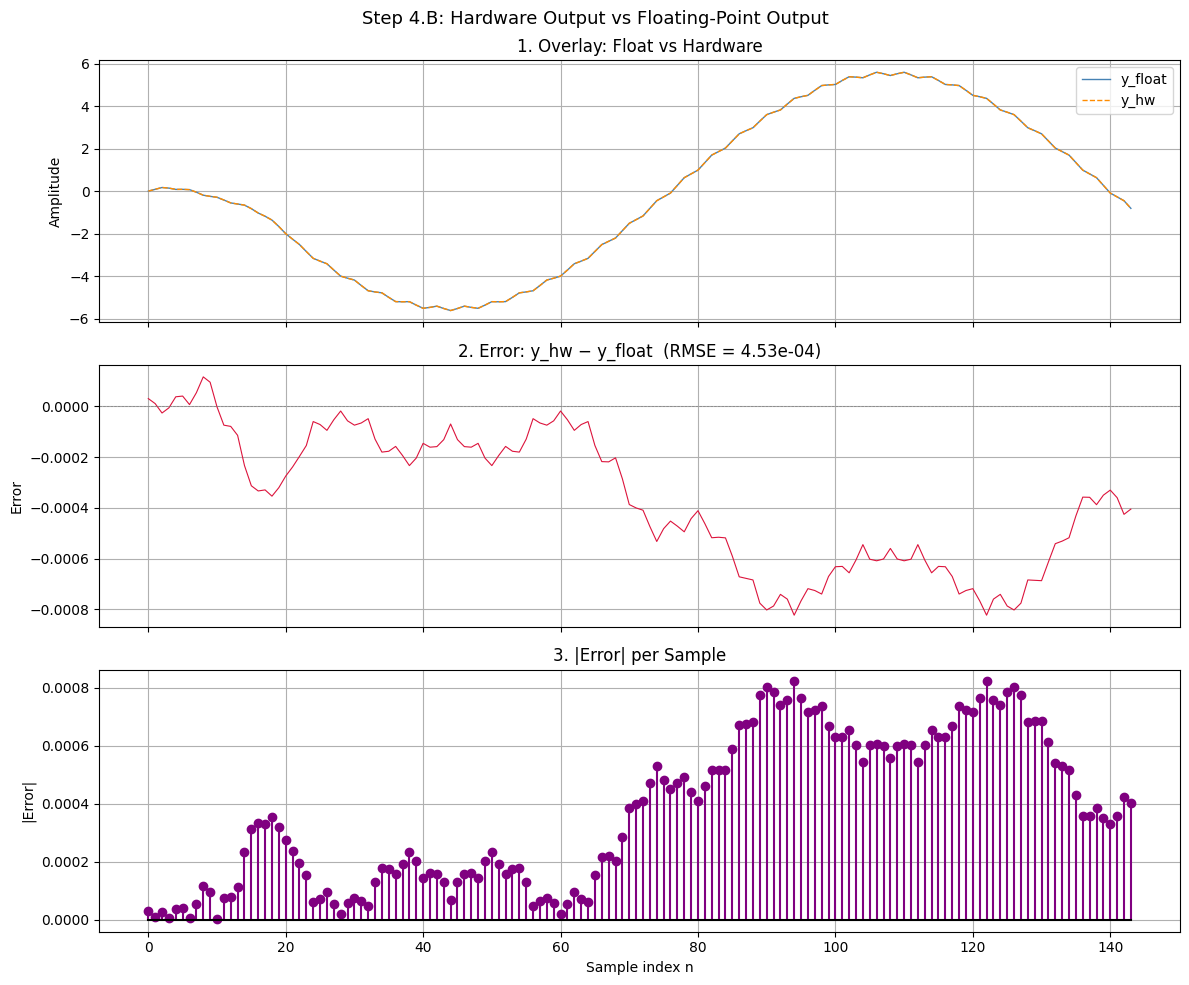

In [ ]:
Y_WIDTH   = 21                      # FilterOut 位寬
FRAC_BITS = b_D                     # 輸出小數位

# 讀取 output.dat（十進位有號整數，每行一筆）
raw = np.loadtxt('../RTL/src/output.dat', dtype=int)

# 定點整數 → 浮點數 
y_hw = raw / (2.0 ** FRAC_BITS)

N_hw = len(y_hw)
n_hw = np.arange(N_hw)

# 對齊長度（取兩者較短的）
L = min(N_hw, len(y_float))
error_hw = y_hw[:L] - y_float[:L]
rmse_hw  = np.sqrt(np.mean(error_hw ** 2))

print(f"Hardware samples : {N_hw}")
print(f"Fractional bits  : {FRAC_BITS}")
print(f"RMSE (HW vs Float) = {rmse_hw:.8f}")
print(f"Threshold 2^-{11}   = {threshold:.8f}")
print(f"{'PASS' if rmse_hw < threshold else 'FAIL'}")

# 畫圖 
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("Step 4.B: Hardware Output vs Floating-Point Output", fontsize=13)

axes[0].plot(np.arange(L), y_float[:L], color='steelblue', linewidth=1, label='y_float')
axes[0].plot(np.arange(L), y_hw[:L],    color='darkorange', linewidth=1, linestyle='--', label='y_hw')
axes[0].set_title("1. Overlay: Float vs Hardware")
axes[0].set_ylabel("Amplitude")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(np.arange(L), error_hw, color='crimson', linewidth=0.8)
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1].set_title(f"2. Error: y_hw − y_float  (RMSE = {rmse_hw:.2e})")
axes[1].set_ylabel("Error")
axes[1].grid(True)

axes[2].stem(np.arange(L), np.abs(error_hw), linefmt='purple', markerfmt='o', basefmt='k-')
axes[2].set_title("3. |Error| per Sample")
axes[2].set_ylabel("|Error|")
axes[2].set_xlabel("Sample index n")
axes[2].grid(True)

plt.tight_layout()
plt.show()